In [1]:
import os
import random
import numpy as np
import scipy.ndimage
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input, Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt

In [2]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    tf.random.set_seed(seed)

In [3]:
def eca_block(x, gamma=2, b=1):
    channels = x.shape[-1]
    k_size = int(abs((np.log2(channels) + b) / gamma))
    k_size = k_size if k_size % 2 else k_size + 1
    avg_pool = layers.GlobalAveragePooling2D()(x)
    avg_pool = layers.Reshape((1, 1, channels))(avg_pool)
    x_eca = layers.Conv1D(1, kernel_size=k_size, padding='same', use_bias=False)(tf.transpose(avg_pool, [0, 3, 1, 2]))
    x_eca = tf.transpose(x_eca, [0, 2, 3, 1])
    x_eca = tf.nn.sigmoid(x_eca)
    return layers.Multiply()([x, x_eca])

In [4]:
def cbam_block(feature_map, ratio=8):
    channel = feature_map.shape[-1]
    avg_pool = layers.GlobalAveragePooling2D()(feature_map)
    max_pool = layers.GlobalMaxPooling2D()(feature_map)
    shared_dense_one = layers.Dense(channel // ratio, activation='relu', kernel_initializer='he_normal')
    shared_dense_two = layers.Dense(channel, kernel_initializer='he_normal')

    avg_out = shared_dense_two(shared_dense_one(avg_pool))
    max_out = shared_dense_two(shared_dense_one(max_pool))
    channel_attention = layers.Add()([avg_out, max_out])
    channel_attention = layers.Activation('sigmoid')(channel_attention)
    channel_attention = layers.Reshape((1, 1, channel))(channel_attention)
    feature_map = layers.Multiply()([feature_map, channel_attention])

    avg_pool_spatial = tf.reduce_mean(feature_map, axis=3, keepdims=True)
    max_pool_spatial = tf.reduce_max(feature_map, axis=3, keepdims=True)
    concat = layers.Concatenate(axis=3)([avg_pool_spatial, max_pool_spatial])
    spatial_attention = layers.Conv2D(1, kernel_size=7, padding='same', activation='sigmoid')(concat)
    feature_map = layers.Multiply()([feature_map, spatial_attention])

    return feature_map

In [5]:
def dense_cbam_block(x, num_layers, growth_rate):
    for _ in range(num_layers):
        y = layers.BatchNormalization()(x)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(4 * growth_rate, kernel_size=1, padding='same', use_bias=False)(y)
        y = layers.BatchNormalization()(y)
        y = layers.Activation('relu')(y)
        y = layers.Conv2D(growth_rate, kernel_size=3, padding='same', use_bias=False)(y)
        y = cbam_block(y)  # CBAM integration
        x = layers.Concatenate()([x, y])
    return x

In [6]:
def transition_block(x, reduction):
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.Conv2D(int(x.shape[-1] * reduction), kernel_size=1, use_bias=False)(x)
    x = layers.AveragePooling2D(pool_size=2, strides=2, padding='same')(x)
    return x

In [7]:
def build_densenet_cbam_eca(input_shape=(224, 224, 3), num_classes=4, growth_rate=32):
    inputs = Input(shape=input_shape)
    x = layers.Conv2D(64, kernel_size=7, strides=2, padding='same', use_bias=False)(inputs)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.MaxPooling2D(pool_size=3, strides=2, padding='same')(x)

    x = dense_cbam_block(x, 6, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_cbam_block(x, 12, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_cbam_block(x, 24, growth_rate)
    x = transition_block(x, 0.5)

    x = dense_cbam_block(x, 16, growth_rate)

    x = eca_block(x)
    x = layers.BatchNormalization()(x)
    x = layers.Activation('relu')(x)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.01))(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = Model(inputs, outputs)
    return model

In [8]:
def create_generators(train_dir, val_dir, test_dir, target_size=(224, 224), batch_size=32):
    datagen = ImageDataGenerator(rescale=1.0 / 255)
    train_gen = datagen.flow_from_directory(train_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical")
    val_gen = datagen.flow_from_directory(val_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical")
    test_gen = datagen.flow_from_directory(test_dir, target_size=target_size, batch_size=batch_size, class_mode="categorical", shuffle=False)
    return train_gen, val_gen, test_gen

In [9]:
def train_model(model, train_gen, val_gen, epochs=20, learning_rate=1e-4):
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss="categorical_crossentropy", metrics=["categorical_accuracy"])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    history = model.fit(train_gen, epochs=epochs, validation_data=val_gen, callbacks=[early_stop])
    return history

In [10]:
def fine_tune_model(model, train_gen, val_gen, fine_epochs=10, fine_lr=1e-5):
    model.trainable = True
    model.compile(optimizer=Adam(learning_rate=fine_lr), loss="categorical_crossentropy", metrics=["categorical_accuracy"])
    early_stop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
    return model.fit(train_gen, epochs=fine_epochs, validation_data=val_gen, callbacks=[early_stop])

In [11]:
def evaluate_model(model, test_gen):
    loss, acc = model.evaluate(test_gen)
    print(f"Test Accuracy: {acc * 100:.2f}%")
    y_true = test_gen.classes
    y_pred = np.argmax(model.predict(test_gen), axis=1)
    print(classification_report(y_true, y_pred, target_names=test_gen.class_indices.keys()))
    cm = confusion_matrix(y_true, y_pred)
    plt.imshow(cm, cmap='Blues')
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.colorbar()
    plt.show()

In [12]:
def plot_history(history, title='Model'):
    plt.figure(figsize=(12, 4))
    plt.subplot(1, 2, 1)
    plt.plot(history.history['categorical_accuracy'], label='Train Accuracy')
    plt.plot(history.history['val_categorical_accuracy'], label='Validation Accuracy')
    plt.legend()
    plt.title(f'{title} Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.legend()
    plt.title(f'{title} Loss')
    plt.show()

In [13]:
def main():
    set_seed()
    dataset_path = r"C:\\Users\\User\\Desktop\\Diseases\\Dataset"
    train_dir = os.path.join(dataset_path, "train")
    val_dir = os.path.join(dataset_path, "val")
    test_dir = os.path.join(dataset_path, "test")

    train_gen, val_gen, test_gen = create_generators(train_dir, val_dir, test_dir)
    model = build_densenet_cbam_eca()
    history = train_model(model, train_gen, val_gen)
    plot_history(history, title="CBAM+ECA DenseNet")

    history_fine = fine_tune_model(model, train_gen, val_gen)
    plot_history(history_fine, title="CBAM+ECA DenseNet Fine-Tuned")

    evaluate_model(model, test_gen)
    model.save("EyeNet_SOTA_Model.h5")
    print("Model saved as EyeNet_SOTA_Model.h5")

Found 36462 images belonging to 4 classes.
Found 7812 images belonging to 4 classes.
Found 7820 images belonging to 4 classes.
Epoch 1/20
1140/1140 [==============================] - 223s 178ms/step - loss: 3.0719 - categorical_accuracy: 0.5955 - val_loss: 2.0423 - val_categorical_accuracy: 0.6056
Epoch 2/20
1140/1140 [==============================] - 179s 157ms/step - loss: 1.2700 - categorical_accuracy: 0.7285 - val_loss: 1.0114 - val_categorical_accuracy: 0.7130
Epoch 3/20
1140/1140 [==============================] - 204s 179ms/step - loss: 0.7016 - categorical_accuracy: 0.7988 - val_loss: 0.8603 - val_categorical_accuracy: 0.7184
Epoch 4/20
1140/1140 [==============================] - 215s 189ms/step - loss: 0.4682 - categorical_accuracy: 0.8525 - val_loss: 0.6339 - val_categorical_accuracy: 0.7732
Epoch 5/20
1140/1140 [==============================] - 203s 178ms/step - loss: 0.3529 - categorical_accuracy: 0.8822 - val_loss: 0.6037 - val_categorical_accuracy: 0.7700
Epoch 6/20
11

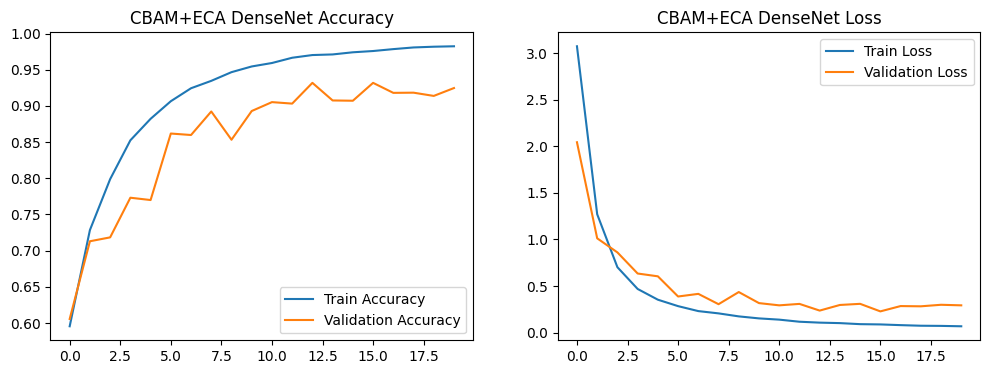

Epoch 1/10
1140/1140 [==============================] - 240s 195ms/step - loss: 0.0302 - categorical_accuracy: 0.9949 - val_loss: 0.1356 - val_categorical_accuracy: 0.9670
Epoch 2/10
1140/1140 [==============================] - 219s 192ms/step - loss: 0.0198 - categorical_accuracy: 0.9976 - val_loss: 0.1350 - val_categorical_accuracy: 0.9675
Epoch 3/10
1140/1140 [==============================] - 220s 193ms/step - loss: 0.0167 - categorical_accuracy: 0.9985 - val_loss: 0.1416 - val_categorical_accuracy: 0.9677
Epoch 4/10
1140/1140 [==============================] - 213s 187ms/step - loss: 0.0158 - categorical_accuracy: 0.9983 - val_loss: 0.1395 - val_categorical_accuracy: 0.9679
Epoch 5/10
1140/1140 [==============================] - 177s 155ms/step - loss: 0.0145 - categorical_accuracy: 0.9987 - val_loss: 0.1338 - val_categorical_accuracy: 0.9674
Epoch 6/10
1140/1140 [==============================] - 176s 155ms/step - loss: 0.0136 - categorical_accuracy: 0.9988 - val_loss: 0.1388 - v

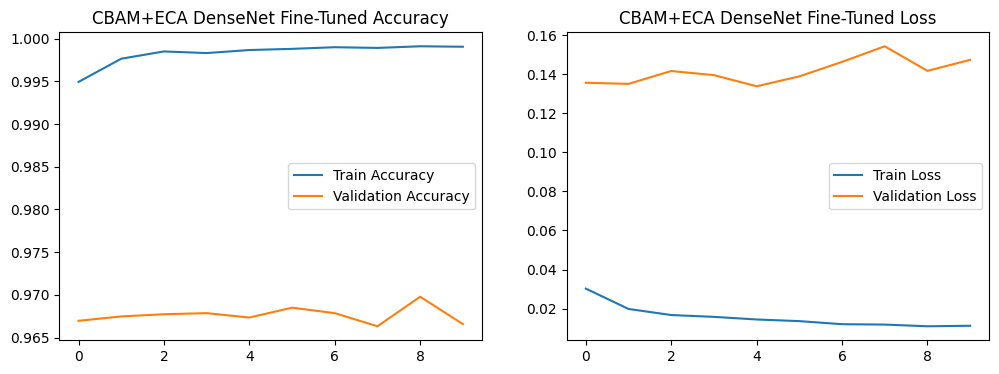

245/245 [==============================] - 14s 59ms/step - loss: 0.1178 - categorical_accuracy: 0.9716
Test Accuracy: 97.16%
245/245 [==============================] - 16s 56ms/step
                precision    recall  f1-score   support

      Cataract       0.96      0.97      0.96      1955
Conjunctivitis       0.98      0.98      0.98      1955
       Healthy       0.97      0.96      0.96      1955
          Stye       0.98      0.98      0.98      1955

      accuracy                           0.97      7820
     macro avg       0.97      0.97      0.97      7820
  weighted avg       0.97      0.97      0.97      7820



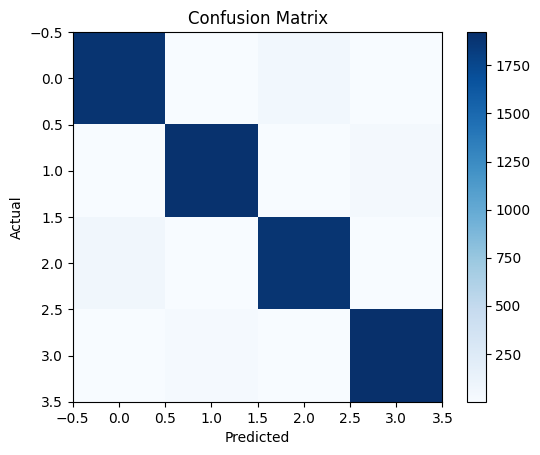

Model saved as EyeNet_SOTA_Model.h5


In [14]:
main()